In [1]:
import re
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.sparse import hstack, csr_matrix
from wordcloud import WordCloud, STOPWORDS

# Sklearn imports
from sklearn.cluster import HDBSCAN, KMeans, AgglomerativeClustering
from sklearn.metrics import make_scorer, silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer

# NLTK imports
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet, stopwords
from nltk import pos_tag
from spacy.lang.en.stop_words import STOP_WORDS as SPACY_STOP_WORDS

# Gensim imports
import gensim
from gensim.models import Word2Vec

# 3D Plotting
from mpl_toolkits.mplot3d import Axes3D

# Custom utility
import text_mining_utils as tmu

# Configuration
warnings.filterwarnings('ignore')
nltk.data.path.append("../../../data/auto/")

# Download NLTK data
nltk_data = [
    'wordnet', 'omw-1.4', 'punkt', 'punkt_tab',
    'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng', 'stopwords'
]
for package in nltk_data:
    try:
        nltk.download(package, download_dir="../../../data/auto/", quiet=True)
    except Exception as e:
        print(f"Warning: Could not download {package}: {e}")

In [2]:
# ==========================================
# Loading data
# ==========================================
try:
    df = pd.read_csv("../../../data/policy/combined_policy_docs_chunked.csv", encoding='utf-8-sig')

    # Ensure titles are strings and handle missing values
    df['Title'] = df['Title'].fillna('').astype(str)

    # Remove rows with failed extraction or missing content
    df = df[df['Content'] != 'N/A']
    df = df.dropna(subset=['Content'])

    # Combine Title and Content for analysis
    df['Content'] = df['Title'] + " " + df['Content']

    print(f"Successfully loaded {len(df)} documents.")
except FileNotFoundError:
    print("Error: File not found. Please run the scraper first.")
    exit()

Successfully loaded 1172 documents.


In [3]:
# ==========================================
# Base stop words initialization
# ==========================================

# Start with SpaCy's comprehensive English list
stop_words = set(SPACY_STOP_WORDS)

# Add Standard NLTK Stopwords
stop_words.update(set(stopwords.words('english')))

# Add French Stopwords
try:
    french_stopwords = set(stopwords.words('french'))
    stop_words.update(french_stopwords)
except:
    print("Warning: French stopwords not found.")

# ==========================================
# Refined domain-specific stopwords
# ==========================================

# PDF & Scraping Artifacts
pdf_stopwords = [
    'pdf', 'qxp', 'page', 'copyright', 'reserved', 'www', 'http', 'https', 'com', 'org',
    'figure', 'table', 'annex', 'appendix', 'footnote', 'endnote',
    'isbn', 'bibliography', 'citation', 'reference', 'metadata', 'docx',
    'executive summary', 'draft', 'matrix', 'blueprint', 'snapshot', 'chart', 'brochure'
]

# Policy, Legal, & Bureaucratic Jargon
# We only remove structural noise and archaic legalese.
# We KEEP abstract nouns (policy, strategy, enjeu, objective) as they are analysis-relevant.

policy_stopwords = [
    # ENGLISH
    
    # STRUCTURAL TERMS (True Noise)
    'section', 'chapter', 'part', 'title', 'article', 'clause', 'paragraph', 'subparagraph',
    'schedule', 'exhibit', 'supplement', 'addendum', 'preamble', 'recital', 'report',
    'coppa', 'ferpa', 'enact', 'bit'
    
    # ARCHAIC CONNECTORS (True Noise)
    'herein', 'therein', 'thereof', 'whereof', 'hereby', 'whereby', 'hereinafter', 'thereafter',
    'aforementioned', 'foregoing', 'henceforth', 'whereto', 'whereupon', 'notwithstanding',
    'pursuant', 'thereto', 'thereunder', 'hereto',

    # GENERIC PROCESS VERBS (Safe to remove)
    'shall', 'must', 'may', 'might', 'could', 'would', 'should', 'will',
    'require', 'requires', 'required', 'ensure', 'ensures', 'seek', 'seeks', 'seeking',
    'establish', 'establishes', 'promote', 'promotes', 'promoting', 'maintain', 'respect',

    # VAGUE QUALIFIERS (Safe to remove)
    'various', 'several', 'multiple', 'certain', 'relevant', 'appropriate',
    'regarding', 'concerning', 'involving', 'accordance', 'relate', 'relates', 'relating',
    'furthermore', 'moreover', 'therefore', 'thus', 'hence', 'however', 'although',
    'including', 'etc', 'etcetera'

    # FRENCH
    
    # STRUCTURAL TERMS
    'article', 'chapitre', 'section', 'partie', 'titre', 'paragraphe', 'alinea', 'annexe',
    'appendice', 'expos', 'des', 'motifs', 'disposition',

    # ARCHAIC CONNECTORS
    'susmentionn', 'prcit', 'nonobstant', 'par drogation', 'en', 'consquence',
    'eu', 'gard', 'aux fins', 'selon', 'conformment', 'outre', 'ladite', 'ledit',

    # GENERIC PROCESS VERBS
    'doit', 'devrait', 'pourrait', 'vouloir', 'exiger', 'requis', 'assurer', 'garantir',
    'rechercher', 'tablir', 'promouvoir', 'maintenir', 'respecter', 'concernant',

    # VAGUE QUALIFIERS
    'divers', 'plusieurs', 'multiple', 'particulier', 'certain', 'aussi',
    'de plus', 'en outre', 'par consquent', 'donc', 'ainsi', 'cependant', 'bien que',
    'notamment', 'entre autres', 'comme', 'ainsi', 'toute', 'tous', 'cette', 'plus', 'leurs'
]

# Geo Noise
geo_stopwords = [
    'ireland', 'irish', 'france', 'french', 'usa', 'america', 'australia', 'australian',
    'country', 'nation', 'national', 'state', 'government', 'federal', 'ministry', 'department',
    'gouvernement', 'ministre', 'dtat', 'republic', 'pittsburg', 'antioch', 'medina', 'winterset', 
    'sara', 'washington', 'california', 'massachusetts', 'oregon', 'sweden', 'unified', 'district'
]

# Tech Noise
tech_stopwords = [
    'artificial', 'intelligence', 'ai', 'lia', 'genai', 'generative', 'model', 'models', 'llm',
    'algorithm', 'algorithms', 'machine', 'learning', 'data', 'dataset', 'datasets', 
    'digital', 'numérique', 'computer', 'software', 'hardware', 'technology', 'technological',
    'platform', 'online', 'internet', 'web', 'electronic', 'tool', 'system', 'device',
    'application', 'app', 'service', 'broadband', 'connectivity', 'vendor', 'player', 'enterprise',
    'artificielle', 'ia', 'gen', 'generatif', 'modle', 'modles', 'apprentissage', 'donn', 'numrique', 
    'ordinateur', 'logiciel', 'matriel', 'technologie', 'plateforme', 'ligne', 'ectronique', 'outil', 
    'systme', 'dispositif', 'générative', 'intelligent', 'edge', 'gpt', 'openai', 'microsoft', 'google', 
    'amazon', 'meta', 'ibm', 'nvidia', 'intel', 'gemini', 'deepseek', 'anthropic', 'claude', 'embedding', 
    'transformer', 'natural language', 'climate change', 'ieee', 'architecture', 'chatgtp', 'copilot', 'kwyk',
    'technologies'
]

# Education Noise
ed_stopwords = [
    'school', 'education', 'educational', 'pupil', 'classroom', 'learning',
    'cole', 'educatif', 'enseignant', 'professeur', 'programme', 'apprentissage',
    'enseignement', 'formation', 'établissement', 'covid', 'showcase', 'deliverable', 
    'post', 'primary', 'technical', 'teacher', 'teachers', 'schools',  'student', 'students',
    'enseignats', 'enseignants', 'élève', 'élèves', 'enseignement', 'éducation', 'école', 'établissement'
]

# Org & Name Noise
org_and_name = [
    'adam', 'mary', 'jensen', 'abraham', 'lincoln', 'knight', 'kim', 
    'guez', 'oecd', 'cbs', 'webwise', 'cosn', 'dlf', 'scoilnet', 'deap', 
    'dne', 'men', 'parliament', 'commissioner', 'public sector', 'cipa', 
    'protection act', 'oide', 'tie', 'cpd', 
]

# Vague Noise
noise = [
    'feel', 'like', 'everybody', 'actually', 'kid', 'employee', 'min', 'box', 'loop', 
    'black', 'asset', 'typical', 'era', 'acquire', 'behavioral', 'behavioural', 
    'revolution', 'emission', 'talent', 'billion', 'count', 'witness', 'operator', 
    'interim', 'resourced', 'resourcing', 'july', 'round', 'support work', 'dashboard', 
    'ela', 'estonia', 'pisa', 'perspectives', 'final', 'total', 'april', 'describe', 'visit',
    'original', 'sample', 'low', 'answer', 'ask', 'efficacy', 'deepen', 'enhance',
    'author', 'researcher', 'mission', 'personnel', 'palo', 'alto', 'winterset', 'card', 
    'use', 'lot', 'enable', 'constituent', 'session', 'policy', 'use', 'august', 'document', 
    'member', 'organisation', 'goal', 'long term', 'desirable', 'young', 'nsw', 'ite', 
    'commonwealth', 'aied', 'australasian', 'perplexed', 'guidetoaiinschools', 'nenufsd', 
    'dent', 'fig', 'fee', 'want', 'prof', 'stu'
]

# Fragments
fragment_stopwords = [
    'ing', 'tion', 'ment', 'ness', 'ly', 'able', 'ive', 'ent', 'ant', 'ence', 'ance', 
    'ali', 'gue', 'rod', 'rodr', 'educa', 'evi', 'al'
]

# MERGE ALL
stop_words.update(pdf_stopwords)
stop_words.update(policy_stopwords)
stop_words.update(geo_stopwords)
stop_words.update(tech_stopwords)
stop_words.update(ed_stopwords)
stop_words.update(fragment_stopwords)
stop_words.update(org_and_name)
stop_words.update(noise)

In [4]:
# ==========================================
# Basic cleaning function
# ==========================================

def clean_text(text):
    """
    Aggressive cleaning for scraped Policy Documents (Multilingual).
    Ensures uniform lowercase and handles French contractions correctly.
    Returns a list of tokens.
    """
    # 1. LOWERCASE FIRST (Crucial to match stopwords)
    text = str(text).lower()
    
    # 2. EXPAND FRENCH CONTRACTIONS (Now that text is lowercase)
    # This prevents "l'IA" from persisting. It becomes "la ia".
    text = re.sub(r"\bl'", "la ", text)
    text = re.sub(r"\bd'", "de ", text)
    text = re.sub(r"\bc'", "que ", text)
    text = re.sub(r"\bj'", "je ", text) # Simplified for "je"
    text = re.sub(r"\bqu'", "que ", text)
    text = re.sub(r"\blorsqu'", "lorsque ", text)
    text = re.sub(r"\bpuisqu'", "puisque ", text)
    
    # 3. Remove Email Addresses
    text = re.sub(r'\S*@\S*\s?', '', text)
    
    # 4. Remove URLs and HTML tags
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'<.*?>', ' ', text)
    
    # 5. Remove Reference Citations
    text = re.sub(r'\[\d+\]', '', text)
    text = re.sub(r'\(\s*see\s+[^\)]+\)', '', text)
    text = re.sub(r'footnote\s*\d+', '', text)
    
    # 6. Remove Punctuation/Separators (Keeps accents)
    # This removes all symbols like ., &, •, etc.
    text = re.sub(r'[^a-zàâäéèêëïîôùûüÿç\s]', '', text)
    
    # 7. Remove Standalone Numbers
    text = re.sub(r'\b\d+\b', ' ', text)

    # 8. Remove HTML entities
    text = re.sub(r'\b(amp|lt|gt|quot|nbsp)\b', ' ', text)

    # 9. Remove single characters
    text = re.sub(r'\s+[a-zàâäéèêëïîôùûüÿç]\s+', ' ', text)
    
    # 10. Tokenize
    words = text.split()
    
    # 11. Filter Stopwords and Short Words
    # ADDED FIX: Explicitly remove common French articles that might be missing
    extra_stopwords = {'la', 'le', 'les', 'de', 'un', 'une', 'des', 'du', 'au', 'aux'}
    filtered_words = [
        word for word in words 
        if word not in stop_words 
        and word not in extra_stopwords  # <-- This removes "la", "lia" (if merged), etc.
        and len(word) > 2
    ]
    
    return filtered_words

print(f"Cleaning {len(df)} documents (keeping accents)...")
# Apply cleaning and join back into strings
df['Clean_Content'] = df['Content'].apply(lambda x: " ".join(clean_text(x)))

# Filter out empty documents
df = df[df['Clean_Content'].str.len() > 0]
print(f"Valid documents after cleaning: {len(df)}")

Cleaning 1172 documents (keeping accents)...
Valid documents after cleaning: 1172


In [5]:
# ==========================================
# Basic statistics
# ==========================================

# Add word count column
df['Word_Count'] = df['Clean_Content'].apply(lambda x: len(x.split())) 

total_words = df['Word_Count'].sum()
avg_words_per_article = df['Word_Count'].mean()
unique_countries = df['Country'].nunique()

print("Basic statistics")
print(f"Total documents/rows: {len(df)}")
print(f"Total countries: {unique_countries}")
print(f"Total words (after cleaning): {total_words}")
print(f"Average words per document: {avg_words_per_article:.2f}")

Basic statistics
Total documents/rows: 1172
Total countries: 4
Total words (after cleaning): 286664
Average words per document: 244.59


Saved: ./img/word_count_distribution.png


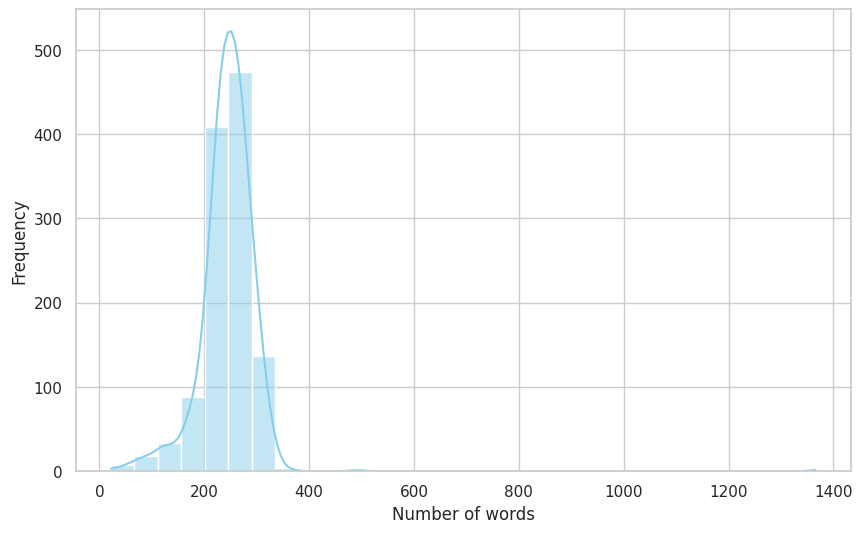

Saved: ./img/doc_count_per_country.png


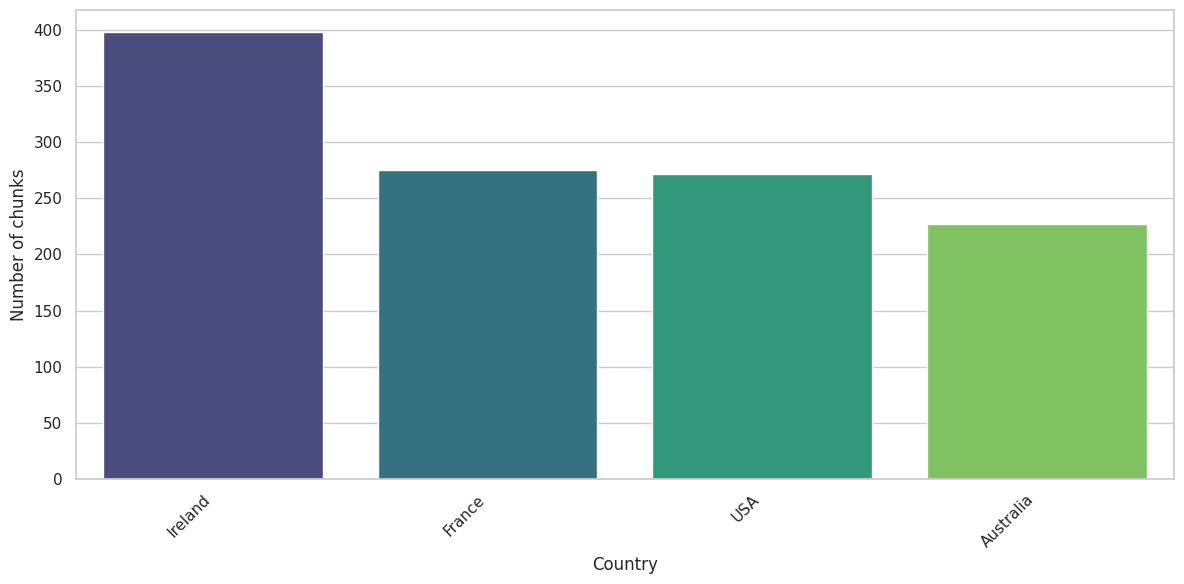

In [6]:
# ==========================================
# Exploratory data analysis
# ==========================================

# Create the directory if it doesn't exist
output_dir = "./img/"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")

# Set general style for plots
sns.set(style="whitegrid")

# A. Distribution of Document Lengths
plt.figure(figsize=(10, 6))
sns.histplot(df['Word_Count'], bins=30, kde=True, color='skyblue')
plt.xlabel('Number of words')
plt.ylabel('Frequency')

# Save the image
save_path = os.path.join(output_dir, 'word_count_distribution.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved: {save_path}")

plt.show()
plt.close()

# B. Document Count per Country
plt.figure(figsize=(12, 6))

# Limit to top 10 countries to keep the chart readable
top_countries = df['Country'].value_counts().nlargest(10).index
sns.countplot(data=df[df['Country'].isin(top_countries)], x='Country', order=top_countries, palette='viridis')
plt.xlabel('Country')
plt.ylabel('Number of chunks')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save the image
save_path = os.path.join(output_dir, 'doc_count_per_country.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved: {save_path}")

plt.show()
plt.close()

Saved: ./img/global_wordcloud.png


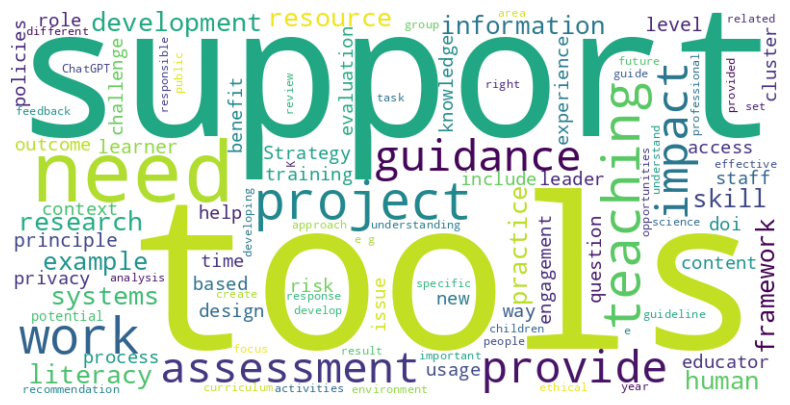

In [7]:
# ==========================================
# Global word cloud
# ==========================================

# Create the directory if it doesn't exist
output_dir = "./img/"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")

def plot_wordcloud(text_data, title, max_words=100, filename=None):
    """Generates, saves, and plots a word cloud."""
    wordcloud = WordCloud(
        stopwords=stop_words,
        background_color='white',
        width=800,
        height=400,
        max_words=max_words
    ).generate(text_data)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    
    if filename:
        save_path = os.path.join(output_dir, filename)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()
    plt.close()

all_text_combined = " ".join(df['Content'])

plot_wordcloud(
    all_text_combined, 
    # 'Top 100 Words in Policy Corpus',
    '',
    filename='global_wordcloud.png'
)

Saved: ./img/wordcloud_ireland.png


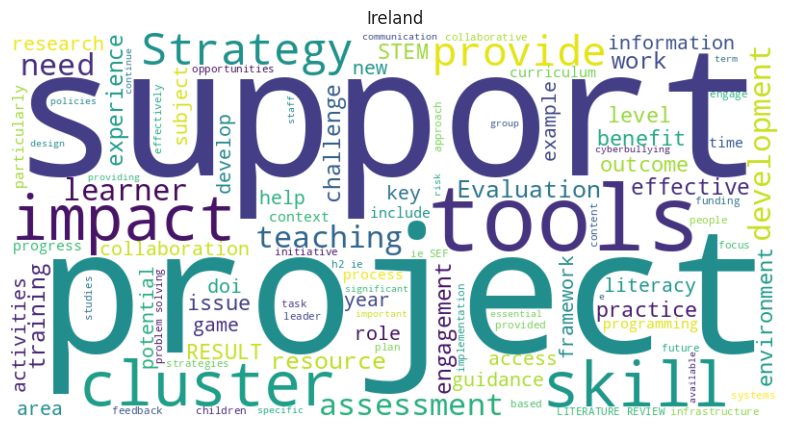

Saved: ./img/wordcloud_france.png


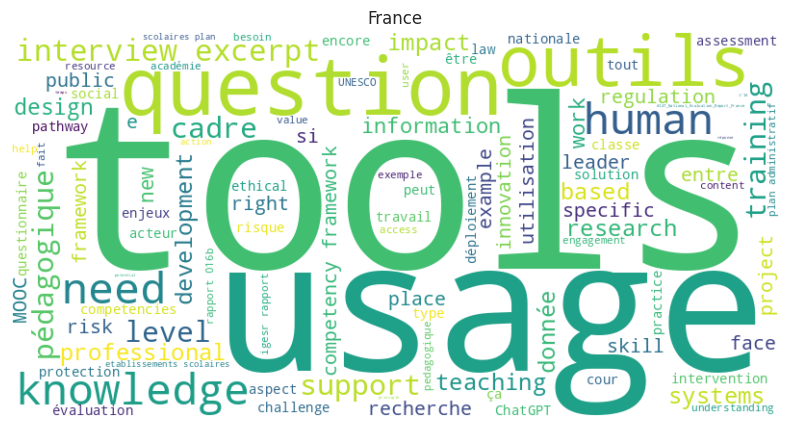

Saved: ./img/wordcloud_usa.png


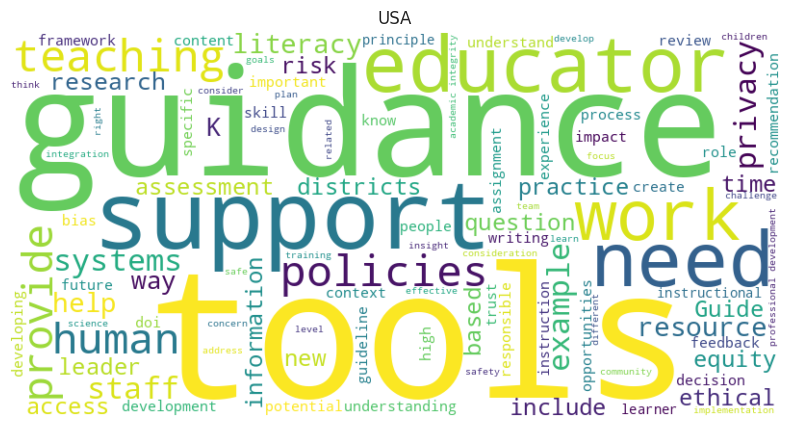

Saved: ./img/wordcloud_australia.png


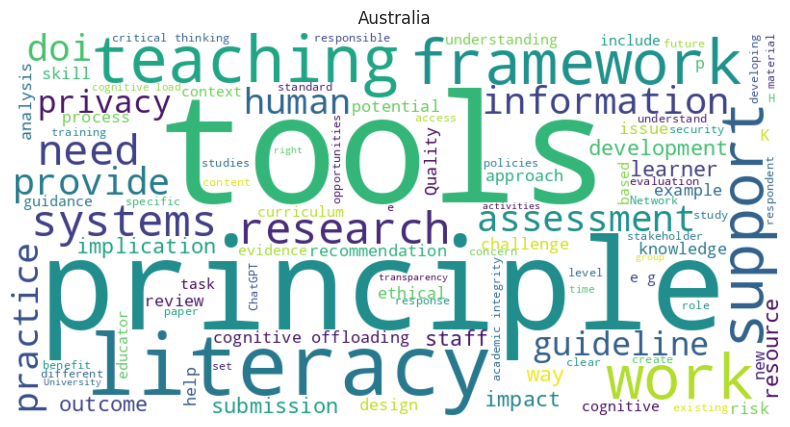

In [8]:
# ==========================================
# Word cloud per country
# ==========================================

top_countries = df['Country'].value_counts().nlargest(4).index

for country in top_countries:
    country_text = " ".join(df[df['Country'] == country]['Content'])
    
    filename = f'wordcloud_{country.lower()}.png'
    
    plot_wordcloud(
        country_text, 
        # f'Top Words in Country: {country}',
        f'{country}',
        filename=filename 
    )


Text Output Preview
tools: 2574
support: 1662
teaching: 1315
development: 1054
skills: 1005
literacy: 957
work: 915
systems: 904
project: 900
impact: 895
research: 886
assessment: 852
guidance: 813
information: 805
human: 788
framework: 753
review: 728
ethical: 722
need: 704
provide: 692
Saved: ./img/top_20_unigrams.png


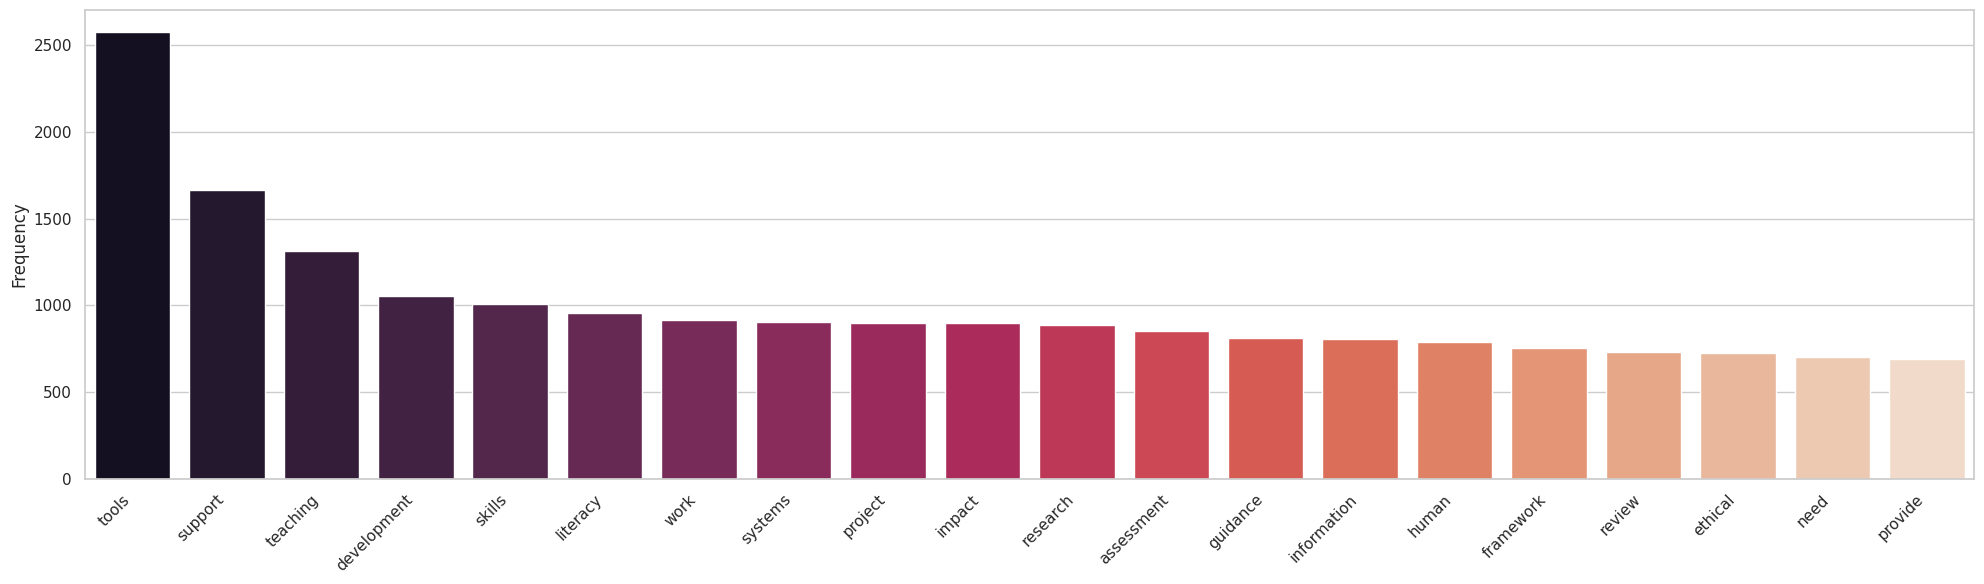

In [9]:
# ==========================================
# Top 20 unigrams bar chart
# ==========================================

# Create the directory if it doesn't exist
output_dir = "./img/"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# USE THE CLEANED DATA HERE: df['Clean_Content']
# This matches the data used in the WordCloud, so the words will be the same.
all_text_combined = " ".join(df['Clean_Content'])

all_words_list = all_text_combined.split()

# Filter out stopwords again (for safety)
filtered_words = [word for word in all_words_list if word not in stop_words and len(word) > 2]

word_counts = Counter(filtered_words)
most_common_words = word_counts.most_common(20)

if len(most_common_words) > 0:
    words, counts = zip(*most_common_words)
else:
    words, counts = [], []
    print("No words found to display.")

# Print to console
print("\nText Output Preview")
for word, count in most_common_words:
    print(f"{word}: {count}")

if len(words) > 0:
    plt.figure(figsize=(20, 6))
    sns.barplot(x=list(words), y=list(counts), palette='rocket')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45, ha='right') 
    plt.tight_layout()

    # Save the image
    save_path = os.path.join(output_dir, 'top_20_unigrams.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {save_path}")

    plt.show()
    plt.close()


Top 20 Words in Ireland
support: 859
project: 776
tools: 742
skills: 646
strategy: 513
impact: 513
teaching: 510
development: 468
assessment: 412
review: 392
key: 386
literacy: 362
effective: 336
evaluation: 335
programming: 335
provide: 333
resources: 328
engagement: 317
work: 315
cluster: 309
Saved: ./img/top_words_ireland.png


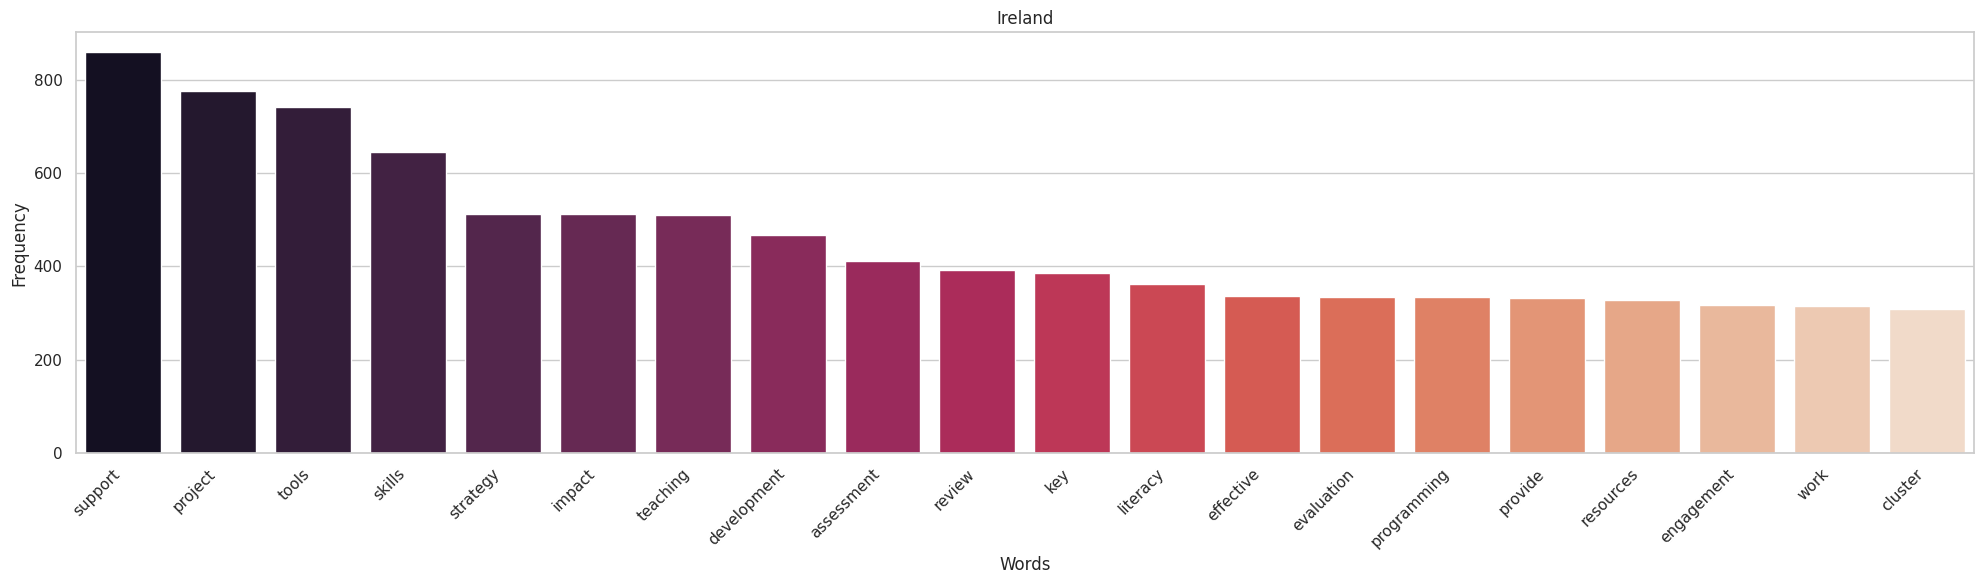


Top 20 Words in France
tools: 468
human: 235
professional: 220
usages: 210
teaching: 198
knowledge: 191
development: 188
outils: 188
interview: 186
support: 183
ethical: 180
excerpt: 179
public: 174
competency: 170
research: 167
training: 165
dune: 165
level: 159
données: 154
systems: 153
Saved: ./img/top_words_france.png


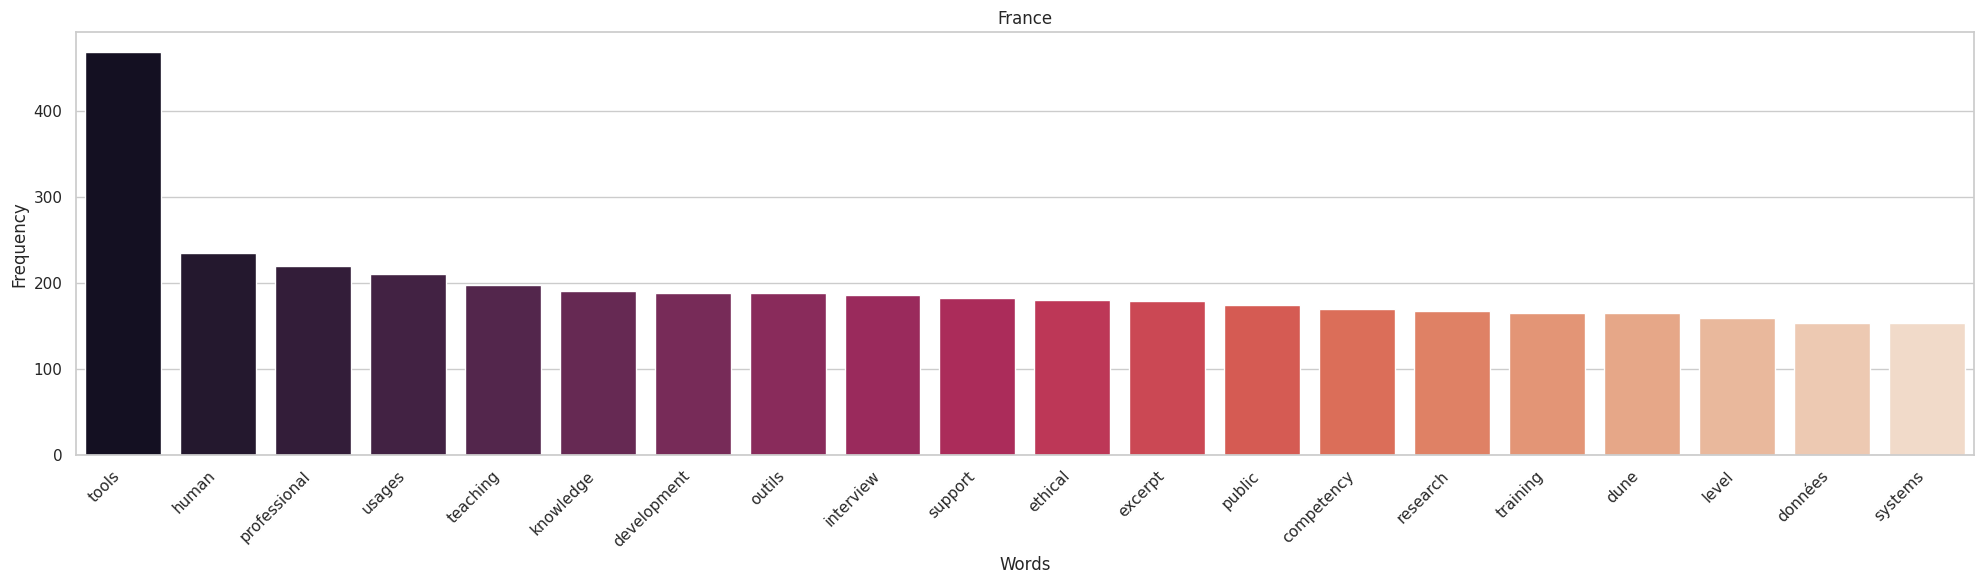


Top 20 Words in USA
tools: 758
support: 387
guidance: 383
educators: 327
systems: 302
teaching: 298
privacy: 293
policies: 274
literacy: 268
work: 262
staff: 258
human: 251
development: 233
ethical: 228
access: 225
districts: 211
need: 211
equity: 200
information: 199
research: 197
Saved: ./img/top_words_usa.png


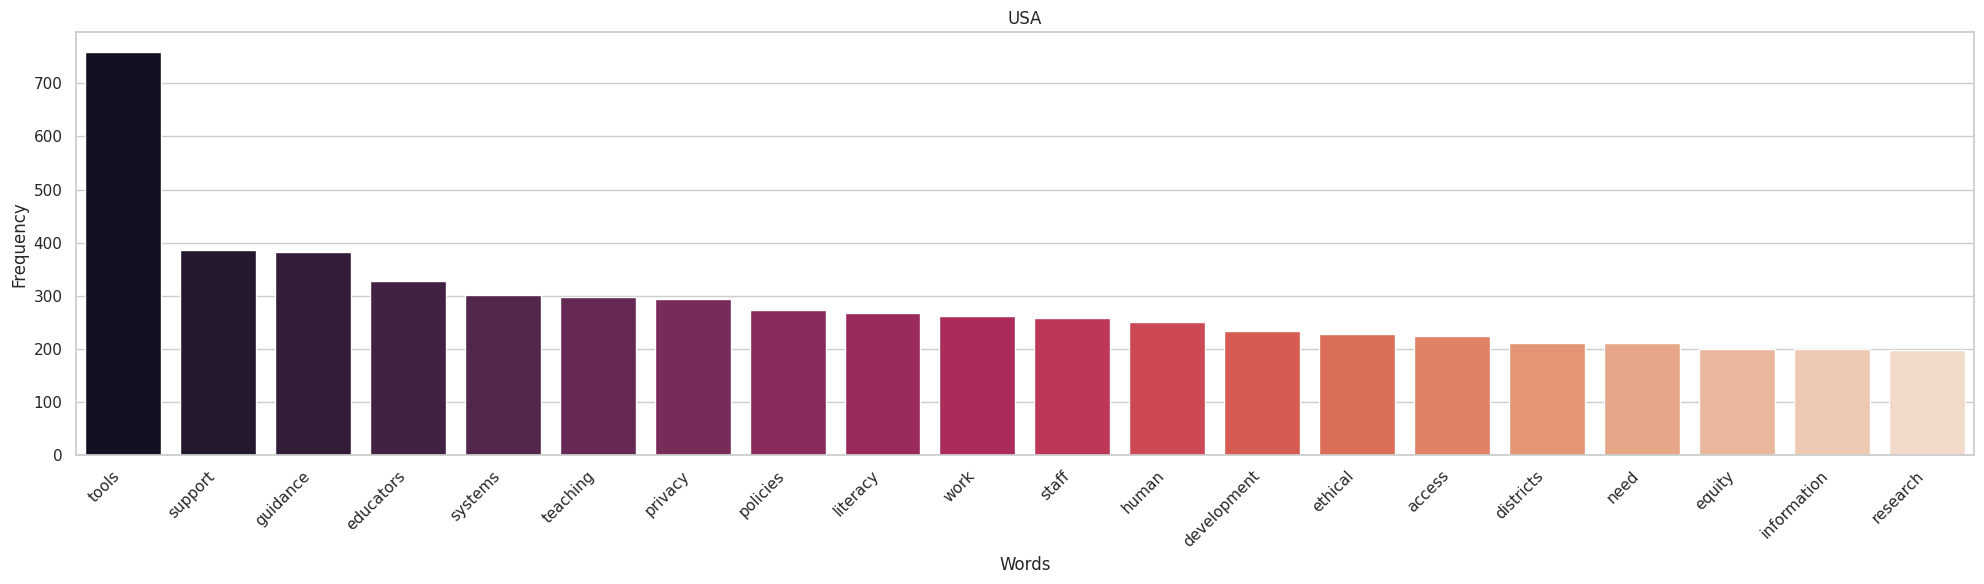


Top 20 Words in Australia
tools: 606
principles: 359
cognitive: 350
literacy: 311
teaching: 309
framework: 300
research: 254
information: 253
systems: 250
work: 247
support: 233
human: 204
assessment: 187
thinking: 186
ethical: 180
privacy: 180
critical: 173
review: 169
staff: 165
development: 165
Saved: ./img/top_words_australia.png


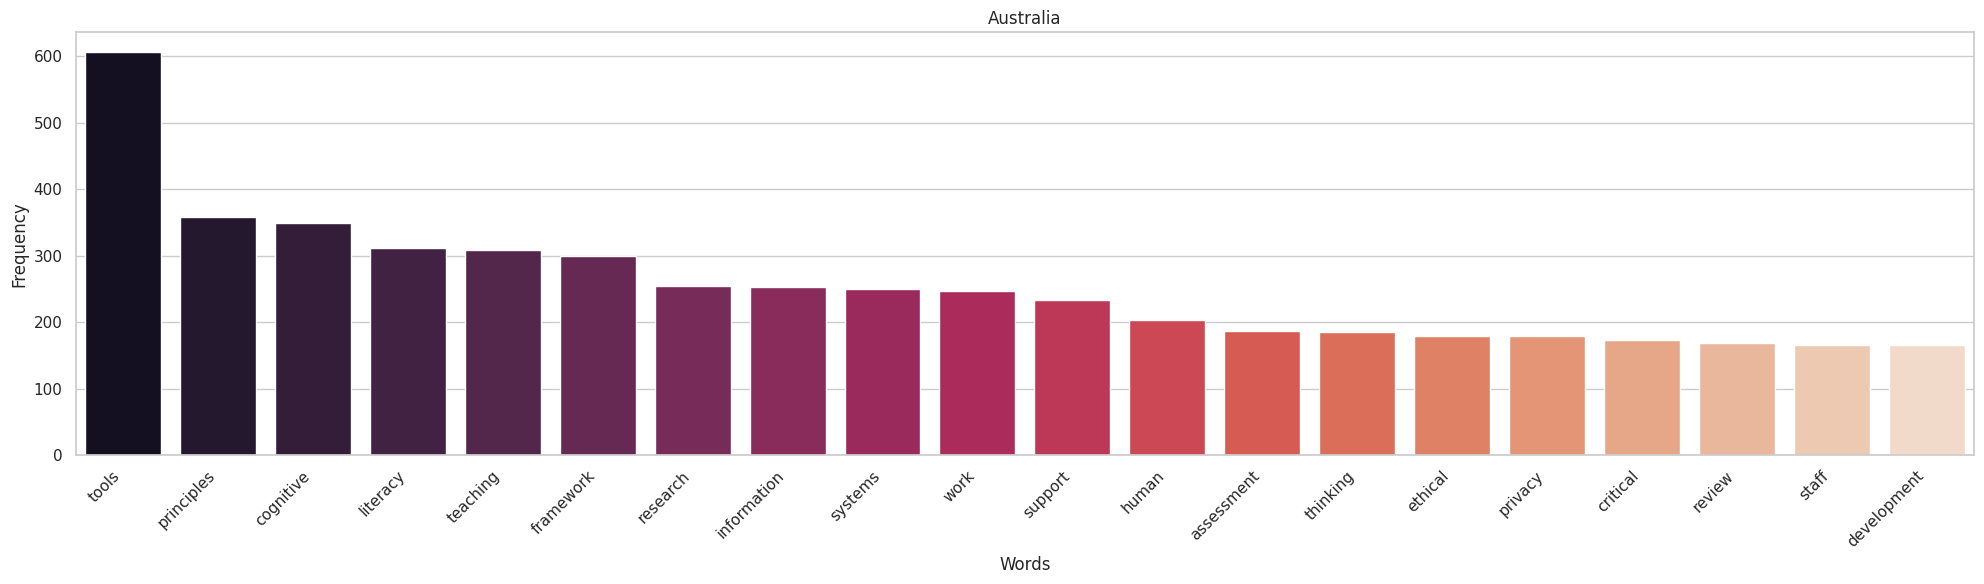

In [10]:
# ==========================================
# Top 20 words per country
# ==========================================


output_dir = "./img/"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Get the list of unique countries
countries = df['Country'].unique()

for country in countries:
    country_df = df[df['Country'] == country]
    
    words_list = " ".join(country_df['Clean_Content']).split()
    
    word_counts = Counter(words_list)
    most_common_words = word_counts.most_common(20)
    
    # Print to console
    print(f"\nTop 20 Words in {country}")
    for word, count in most_common_words:
        print(f"{word}: {count}")
    
    # Unpack into lists for plotting
    words, counts = zip(*most_common_words)
    
    # Plot
    plt.figure(figsize=(20, 6))
    sns.barplot(x=list(words), y=list(counts), palette='rocket')
    plt.title(f'{country}')
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    
    # Rotate the x-axis labels
    plt.xticks(rotation=45, ha='right') 
    
    plt.tight_layout()
    
    # Save the image
    safe_country_name = country.lower().replace(" ", "_")
    filename = f'top_words_{safe_country_name}.png'
    save_path = os.path.join(output_dir, filename)
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {save_path}")
    
    plt.show()
    plt.close()